In [1]:
# 1. 데이터 로딩
import pandas as pd

df = pd.DataFrame({
    "study_hours": [1,2,2,3,3,4,4,5,5,6,6,7,7,8,8,2,3,5,6,7,4,5,6,8,9], # 하루 평균 공부 시간
    "attendance_rate": [60,65,70,72,75,78,80,82,84,85,87,88,90,92,95,68,74,83,86,91,79,81,88,94,96], # 출석률
    "sleep_hours": [5,6,5,6,7,6,7,7,8,6,7,8,7,8,7,5,6,7,6,8,7,6,7,8,7], # 평균 수면 시간
    "assignment_score": [40,50,55,58,60,65,68,72,74,78,80,84,86,90,92,52,59,73,79,88,66,71,82,91,95], #과제 평균 점수
    "youtube_hours": [5,4,5,4,3,3,2,2,2,2,1,1,1,1,1,4,3,2,2,1,3,2,1,1,1], # 하루 유튜브 시청 시간
    "game_hours": [4,3,4,3,3,2,2,2,1,1,1,1,1,0,0,4,3,2,1,1,2,2,1,0,0], # 하루 게임 시간
    "exercise_hours": [0,0,1,1,1,1,2,2,2,2,2,3,3,3,3,1,1,2,2,3,2,2,2,3,3], # 운동 시간
    "final_score": [45,50,53,58,61,66,69,73,76,80,83,87,89,93,95,54,60,75,81,90,68,74,84,94,98] # 점수
})

df

,study_hours,attendance_rate,sleep_hours,assignment_score,youtube_hours,game_hours,exercise_hours,final_score
0,1,60,5,40,5,4,0,45
1,2,65,6,50,4,3,0,50
2,2,70,5,55,5,4,1,53
3,3,72,6,58,4,3,1,58
4,3,75,7,60,3,3,1,61
5,4,78,6,65,3,2,1,66
6,4,80,7,68,2,2,2,69
7,5,82,7,72,2,2,2,73
8,5,84,8,74,2,1,2,76
9,6,85,6,78,2,1,2,80


In [2]:
# 2. 데이터 전처리 (결측치, 이상치, 데이터 분포 등 확인)
df.info()

# 확인 결과
# 관측되는 결측치는 없고 모든 칼럼이 정수형
# 모두 수치 데이터이므로 별도의 형변환은 필요하지 않다고 판단됨

<class 'pandas.DataFrame'>
RangeIndex: 25 entries, 0 to 24
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   study_hours       25 non-null     int64
 1   attendance_rate   25 non-null     int64
 2   sleep_hours       25 non-null     int64
 3   assignment_score  25 non-null     int64
 4   youtube_hours     25 non-null     int64
 5   game_hours        25 non-null     int64
 6   exercise_hours    25 non-null     int64
 7   final_score       25 non-null     int64
dtypes: int64(8)
memory usage: 1.7 KB


In [3]:
df.describe()

,study_hours,attendance_rate,sleep_hours,assignment_score,youtube_hours,game_hours,exercise_hours,final_score
count,25.000000,25.000000,25.000000,25.000000,25.00000,25.000000,25.000000,25.000000
mean,5.040000,81.720000,6.680000,72.320000,2.28000,1.760000,1.880000,74.240000
std,2.207563,9.650216,0.945163,14.817557,1.30767,1.267544,0.927362,15.414495
min,1.000000,60.000000,5.000000,40.000000,1.00000,0.000000,0.000000,45.000000
25%,3.000000,75.000000,6.000000,60.000000,1.00000,1.000000,1.000000,61.000000
50%,5.000000,83.000000,7.000000,73.000000,2.00000,2.000000,2.000000,75.000000
75%,7.000000,88.000000,7.000000,84.000000,3.00000,3.000000,3.000000,87.000000
max,9.000000,96.000000,8.000000,95.000000,5.00000,4.000000,3.000000,98.000000


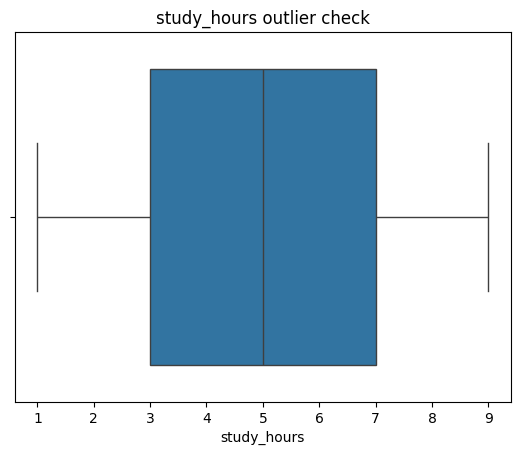

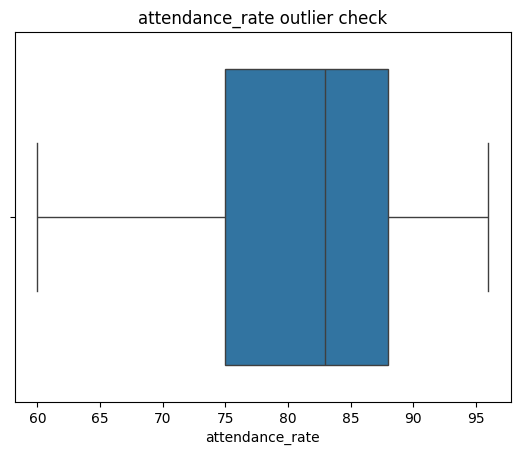

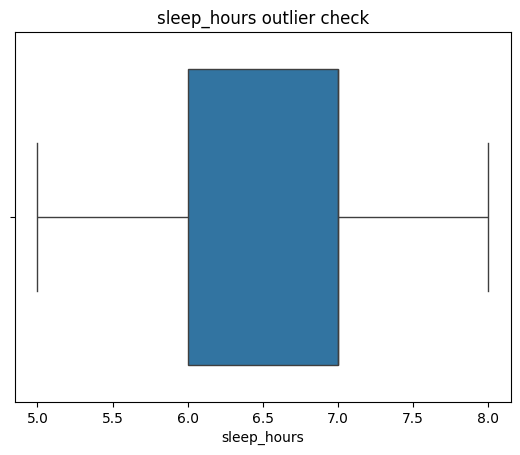

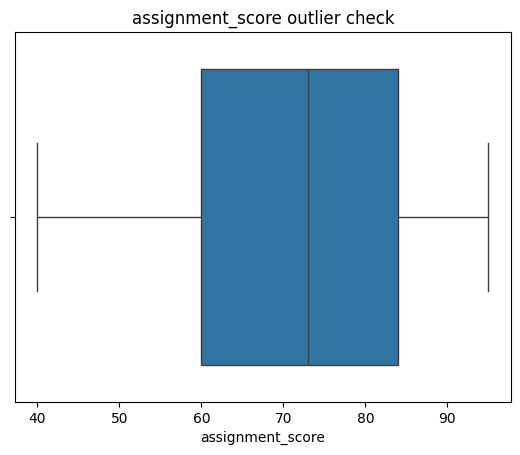

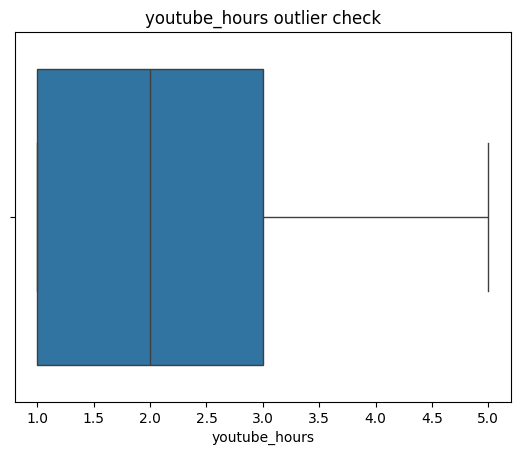

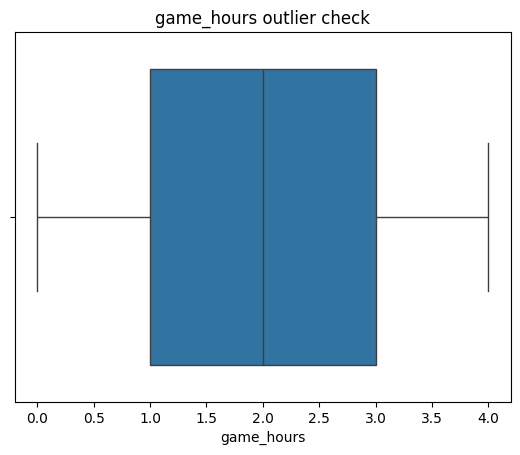

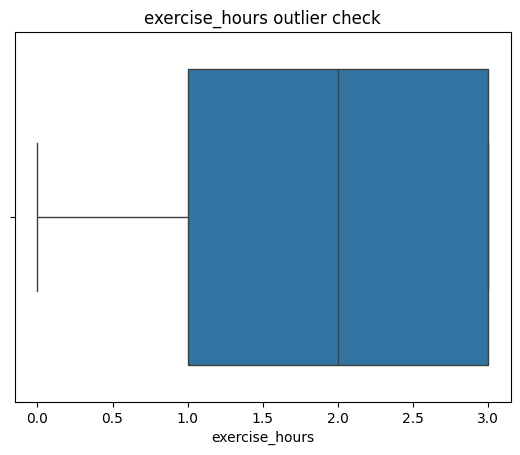

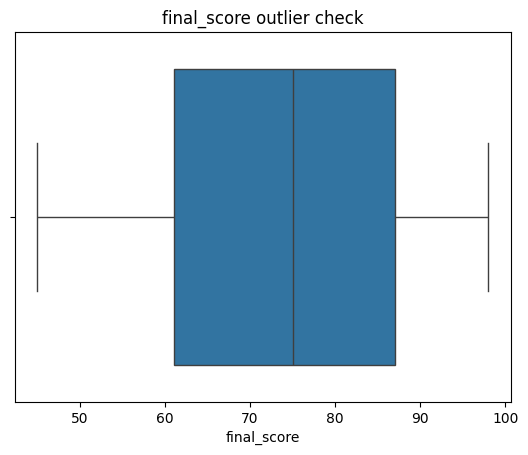

In [5]:
import matplotlib.pyplot as plt 
import seaborn as sns

for column in df.columns:
    sns.boxplot(data=df, x=column)
    plt.title(column + " outlier check")
    plt.show()
# 데이터의 모든 칼럼에 이렇다 할 이상치는 발견되지 않음
# 별도의 처리 없이 로드된 데이터를 그대로 쓰면 될 것 같음

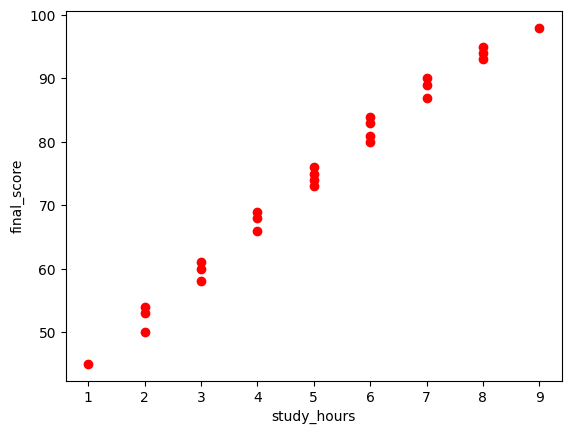

In [6]:
# 3. 데이터 시각화
# 학생들의 학습 습관 및 생활 패턴이
# 최종 시험 점수에 어떤 영향을 미치는 지 알아보는 것이 목적
# study_hours(하루 평균 공부 시간), attendance_rate(출석률), sleep_hours(평균 수면 시간)
# 3개의 칼럼이 최종 시험 점수에 영향이 제일 미칠 것으로 판단했음
plt.scatter(df["study_hours"], df["final_score"], color="red")
plt.xlabel("study_hours")
plt.ylabel("final_score")
plt.show()

## 분석 결과 : 하루 평균 공부 시간이 많을수록 최종 성적이 높게 나오는 것을 확인했음
##            이에 따라 하루 평균 공부 시간은 최종 성적에 영향을 미치는 것으로 확인됨 

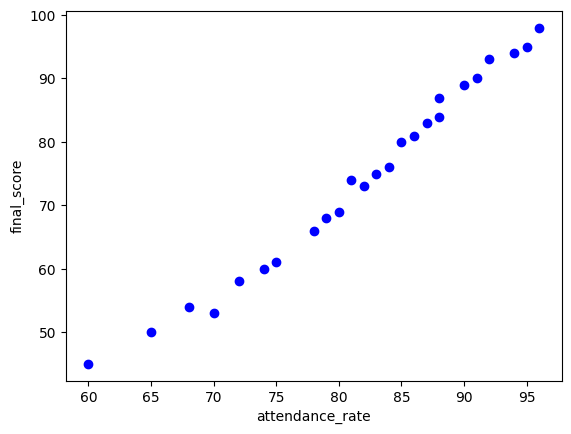

In [7]:
plt.scatter(df["attendance_rate"], df["final_score"], color="blue")
plt.xlabel("attendance_rate")
plt.ylabel("final_score")
plt.show()
## 분석 결과 : 출석률이 높을수록 최종 성적이 높게 나오는 것을 확인했음
##            하루 평균 공부 시간과 마찬가지로 최종 성적에 영향을 미치는 것으로 확인됨

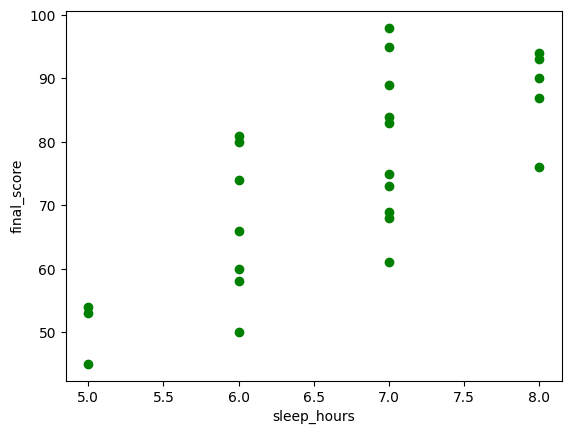

In [8]:
plt.scatter(df["sleep_hours"], df["final_score"], color="green")
plt.xlabel("sleep_hours")
plt.ylabel("final_score")
plt.show()
## 분석 결과 : 평균 수면 시간이 많다고 해서 무조건 최종 성적이 잘나오는 것은 아님
##            따라서 해당 칼럼은 학습 데이터로 적절하지 않다고 판단함

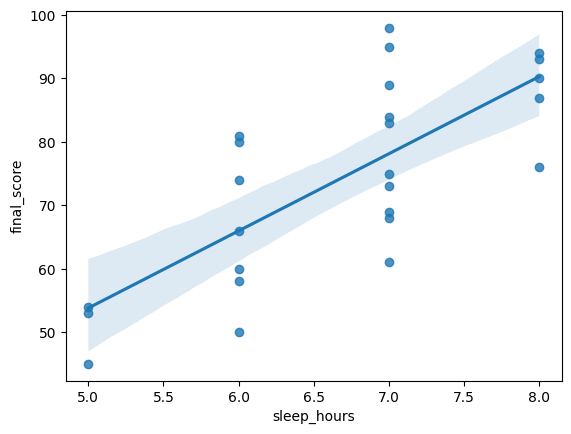

In [9]:

sns.regplot(data=df, x="sleep_hours", y="final_score")
plt.show()

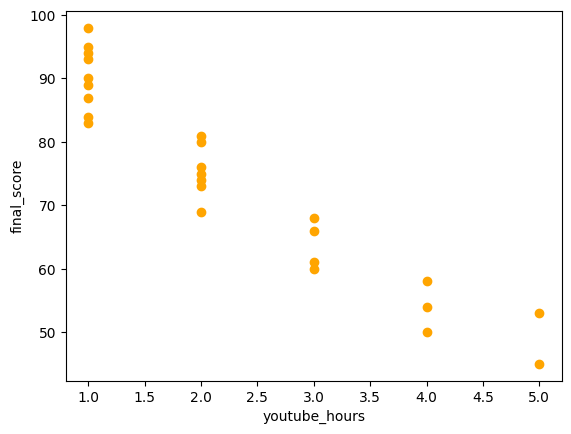

In [10]:
## 유튜브 시청 시간(youtube_hours)를 분석해보기로 함
plt.scatter(df["youtube_hours"], df["final_score"], color="orange")
plt.xlabel("youtube_hours")
plt.ylabel("final_score")
plt.show()
## 분석 결과 : 유튜브 시청 시간이 적을수록 최종 성적이 높게 나오는 것을 확인했음
##            유튜브 평균 시간이 최종 성적에 영향을 미치는 것으로 확인했음

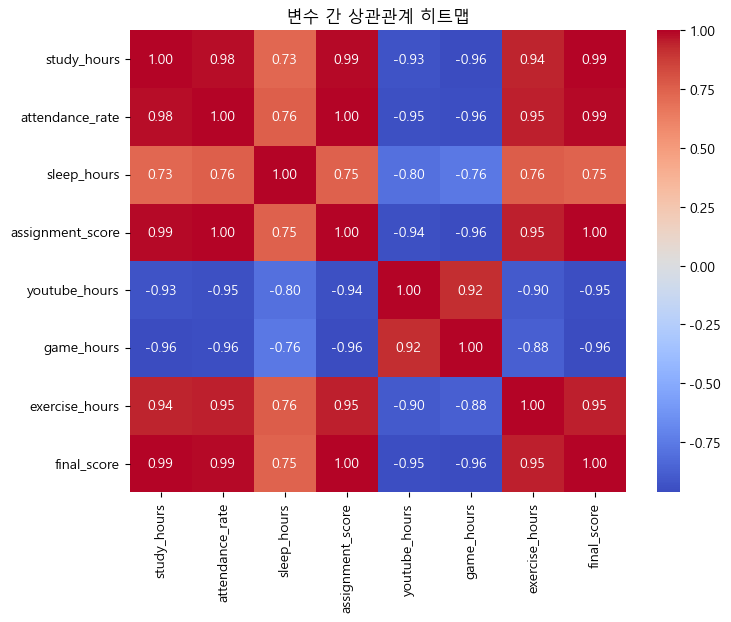

In [12]:
import matplotlib.pyplot as plt
# 한글 깨짐 해결
plt.rcParams['font.family'] = 'Malgun Gothic'   # 윈도우
plt.rcParams['axes.unicode_minus'] = False

# 상관계수 계산
corr = df.corr(numeric_only=True)

# 히트맵
plt.figure(figsize=(8,6))

sns.heatmap(
    corr,
    annot=True,      # 숫자 표시
    cmap="coolwarm", # 색상
    fmt=".2f"        # 소수점 2자리
)

plt.title("변수 간 상관관계 히트맵")
plt.show()

In [11]:
# 4. 데이터 셋 나누기
from sklearn.model_selection import train_test_split

X = df[["study_hours", "attendance_rate", "youtube_hours"]] # 문제 데이터
y = df["final_score"] # 정답 데이터

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
    # 70%는 학습 데이터, 30%는 테스트 데이터로 사용
    # 데이터들을 무작위로 섞어서 과적합을 방지
)

In [88]:
# 5. 모델 만들고 학습
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X_train, y_train)

print("기울기", model.coef_)
print("절편", model.intercept_)

기울기 [ 3.44151882  0.65943866 -1.33183141]
절편 5.986201070121112


In [89]:
# 6. 평가
# 미리 만들어둔 X_test 값으로 학습시켜 나온 예측값와
# y_test 즉, 실제값의 차이를 비교하여 모델을 평가

y_pred = model.predict(X_test)
print(y_pred) # 예측값
print(y_test) # 실제값
# 비교 결과 적게는 소수점 이하의 차이, 많게는 3점 내외의 차이가 나는 것을 확인
# 더 정확한 평가를 위해 MSE, RMSE, R2(제곱임) 계수로 평가해보기로 함
from sklearn.metrics import mean_squared_error, r2_score

# MSE : 실제값과 예측값의 차이의 제곱으로 평균을 낸 값
mse = mean_squared_error(y_test, y_pred)
print("mse:", mse)

# RMSE : 예측값이 평균 얼마나 오류가 날 수 있는지 알려줌
import numpy as np
rmse = np.sqrt(mse)
print("rmse:", rmse)

# R2 : 모델이 얼마나 정확한지 판단
# 1.0이면 완벽 예측, 0.8 이상이면 좋음
# 0이면 평균으로 예측하는 것과 동일, 0이하면 평균을 내는 것보다 못한 예측
r2 = r2_score(y_test, y_pred)
print("r2 score:", r2)

## 분석 결과 : 실제값과 예측값의 차이가 약 2정도가 나며, 1.3 정도의 예측치에 오류가 발생할 수 있으며
##            모델이 99% 정확도를 가진 예측을 할 수 있다고 평가됨
##            성능이 좋은 모델로 학습되었다는 것을 알 수 있음 

[75.92297944 61.11372383 42.33488219 94.17375387 86.77560312 80.02393692
 92.85487656 50.4054257 ]
8     76
16    60
0     45
23    94
11    87
9     80
13    93
1     50
Name: final_score, dtype: int64
mse: 1.0769642534904713
rmse: 1.0377688825024922
r2 score: 0.9966565262079364


In [83]:
# 7. 새로운 값 예측
# 경고 메시지 없애는 방법
# 이유 : sklearn에서 데이터 순서가 뒤섞이지 않도록 칼럼명의 명시해달라고 요청했기 때문
#        치명적인 오류는 아니지만, 새로운 값을 예측할 때 학습할 때와 동일하게 컬럼명을 지정해주는 것이 좋음
# new_X = pd.DataFrame([[8, 98, 1],
#          [4, 82, 3],
#          [1, 65, 6]], columns=["study_hours", "attendance_rate", "youtube_hours"])

new_X = [[8, 98, 1], # 모범생
         [4, 82, 3], # 적당히 놀고 공부하는 학생
         [1, 65, 6]] # 학교 빼먹고 놀기만 하는 학생

new_y = model.predict(new_X)
print(new_y)


outlier_x = [[16, 20, 2], # 출석률은 낮은데 공부는 많이 하는 학생
             [0, 100, 0], # 출석만 하고 공부도 유튜브도 안보는 학생
             [5, 45, 12]] # 공부는 안하고 유튜브만 보는 학생

outlier_y = model.predict(outlier_x)
print(outlier_y)

[96.8115085  69.8307519  44.30024406]
[71.5756125  71.93006665 36.88655778]


c:\AI\Linear\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
c:\AI\Linear\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
